In [87]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
# Sklearn dataset 
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score,
    root_mean_squared_error,
    mean_absolute_error,
    mean_squared_error
)
from sklearn.linear_model import LinearRegression,LassoCV,RidgeCV

In [88]:
diab=load_diabetes()
X=diab['data']
y=diab['target']
#printing shapes
print(X.shape, y.shape)
#creating dataframe from X

df = pd.DataFrame(X, columns=["age","sex","bmi","bp", "tc", "ldl", "hdl","tch", "ltg", "glu"])


#showing head
df.head()
# Lets Explore the dataset 
print(f'Shape of the Dataset : {df.shape}')
print("Info of the Dataset :")
df.info()
print("-- Statistical Description of the Dataset --")
df.describe().T


(442, 10) (442,)
Shape of the Dataset : (442, 10)
Info of the Dataset :
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   tc      442 non-null    float64
 5   ldl     442 non-null    float64
 6   hdl     442 non-null    float64
 7   tch     442 non-null    float64
 8   ltg     442 non-null    float64
 9   glu     442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB
-- Statistical Description of the Dataset --


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
tc,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
ldl,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
hdl,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
tch,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
ltg,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
glu,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


Diabetes Dataset Analysis :
1. The dataset consists of all numeric Features and has no missing values hence we dont have to handle any missing values here.
2. We have 422 rows of data and 10 features like Age,Sex,BMI,BP and S1-S6 are blood serum values for various parameters like LDL,HDL etc


# Exploratory Data Analysis


Univariant Analysis :
- Since all Feature columns are numeric we ll build histogram to see te distribution and skewness
- We will also build boxplot to detect outliers if any .

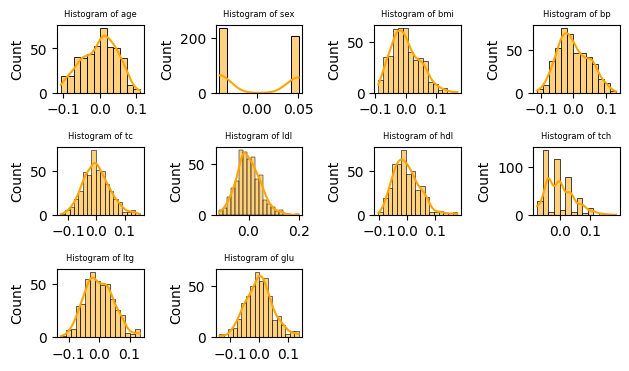

In [89]:
num_col=df.columns.tolist()  # list of all numeric columns
#Plotting histograms
plt.Figure(figsize=(15,12))
for i,col in enumerate(num_col):
    axes=plt.subplot(4,4,i+1)
    sns.histplot(data=df,x=col,kde=True,color='orange')
    plt.title(f'Histogram of {col}',fontsize=6)
    plt.xlabel('')
plt.tight_layout()
plt.show()   


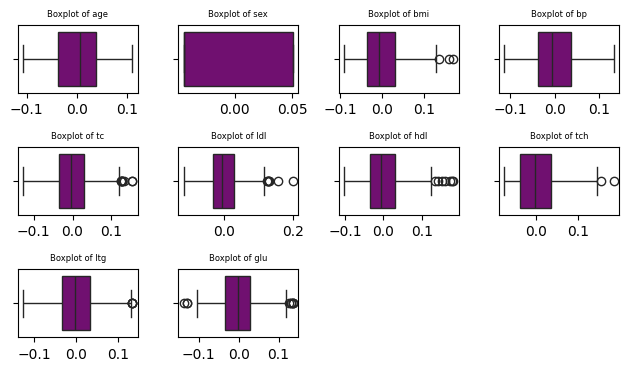

In [90]:
#Plotting boxplot
plt.Figure(figsize=(15,12))
for i,col in enumerate(num_col):
    axes=plt.subplot(4,4,i+1)
    sns.boxplot(data=df,x=col,color='purple')
    plt.title(f'Boxplot of {col}',fontsize=6)
    plt.xlabel('')
plt.tight_layout()
plt.show()   

- Histograms depicts normal distribution in most of the features. 
- Boxplots are mostly having a uniform box width, we sight some outliers , but we will have to check if they are actually outliers or not.

Bivariant Analysis :
- We will build a correlation heatmap to see how features are related with each other.
- Also we will build pairplot to check relationship btween few of the features with the target.

<Axes: >

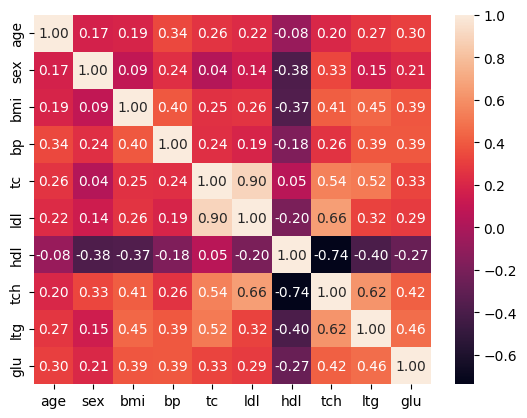

In [91]:
# Correlation Heatmap
correlation_matrix=df[num_col].corr()
sns.heatmap(correlation_matrix,fmt='.2f',annot=True)

-From the above Heatmap we notice that the features dont show very high correlation .

-Next lets visualize relationship between some features like BMI,AGE,ltg with the target .

<Figure size 1000x700 with 0 Axes>

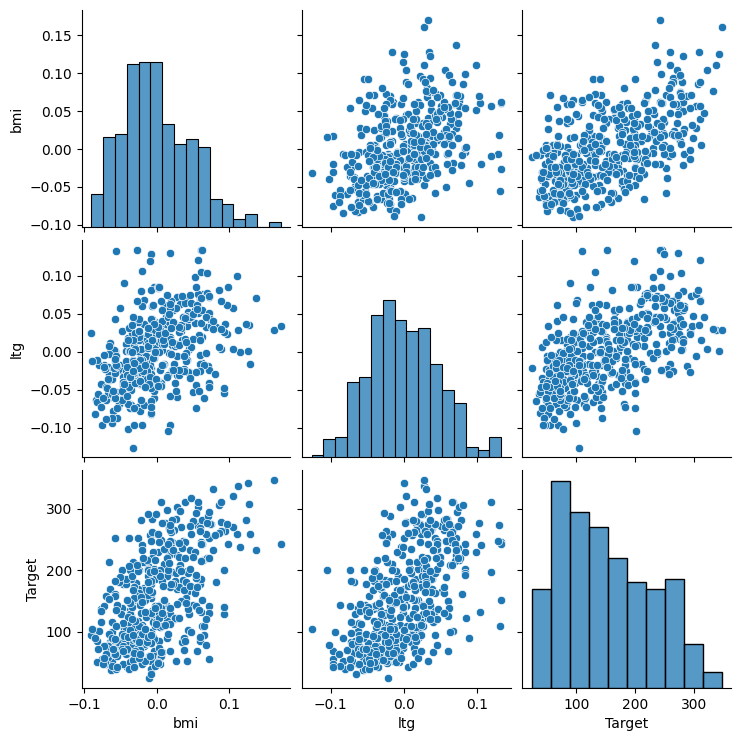

In [92]:
df['Target']=y
#figure size
plt.figure(figsize=(10, 7))
#plotting graphs
sns.pairplot(df[['bmi', 'ltg', 'Target']])

In [116]:
df=df.drop(columns='Target')

Looking at the above Pairplot , we see that the features seem to have a Linear relationship with the Target.
We will choose a Linear regression Model first and then evaluate the test results.

# Model Selection -Linear Regression 


In [127]:

# Split the train test data
X_train,X_test,y_train,y_test=train_test_split(df,y,test_size=0.2,random_state=42)
#Pipeline creation 
lin_model =Pipeline([
    ('scaler',StandardScaler()),
    ('Linear',LinearRegression())
])
# Train your linear regression model 
lin_model.fit(X_train,y_train)

#Test Your model 
y_pred=lin_model.predict(X_test)

#Evaluate your model 
print(f'R2-score:{r2_score(y_test,y_pred):.2f}')
print(f'MSE:{mean_squared_error(y_test,y_pred):.2f}')
print(f'MAE:{mean_absolute_error(y_test,y_pred):.2f}')

R2-score:0.45
MSE:2900.19
MAE:42.79


We need to improvise our model as the r2 score is quite low . Closer to 1 R2 score means a better model.

# Ridge and Lasso Regression 

In [126]:
alphas=np.logspace(-4,4,100)
# Ridge model 
ridge_model = Pipeline([
("scaler",StandardScaler()),
("ridge",RidgeCV(alphas=alphas, cv=5))


])
#Lasso Model
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(alphas=alphas, cv=5, max_iter=20000))
])
# Train the model 
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

#predict and evaluate
y_pred_r=ridge_model.predict(X_test)
y_pred_l=lasso_model.predict(X_test)

#Evaluate your model 
print(f'R2-score for Ridge Model:{r2_score(y_test,y_pred_r):.2f}')
print(f'MSE for Ridge Model:{mean_squared_error(y_test,y_pred_r):.2f}')
print(f'MAE for Ridge Model:{mean_absolute_error(y_test,y_pred_r):.2f}')

print(f'R2-score for Lasso Model:{r2_score(y_test,y_pred_l):.2f}')
print(f'MSE for Lasso Model:{mean_squared_error(y_test,y_pred_l):.2f}')
print(f'MAE for Lasso Model:{mean_absolute_error(y_test,y_pred_l):.2f}')


R2-score for Ridge Model:0.46
MSE for Ridge Model:2859.10
MAE for Ridge Model:42.98
R2-score for Lasso Model:0.47
MSE for Lasso Model:2800.95
MAE for Lasso Model:42.78


We notice that our Lasso model R2 score is the best so far with a score of 0.47. R2 score has improved slightly from our basic linear model show casing r2 score of 0.45 to our lasso model 0.47. 
We can also check other regression model to see if our model performs better like Decision Tree Regressor model. 